# 03 — Robustesse et limites de la méthode

Ce notebook questionne la validité statistique des résultats des notebooks 01 et 02.

**Questions posées :**
1. Les différences de shifts entre LLMs sont-elles statistiquement significatives ? (Bootstrap CI + permutation)
2. La signature d'un modèle est-elle robuste à un changement de prompt ? (P1 vs P2)
3. Le signal se dégrade-t-il sur les textes courts ?
4. Quelle est la variance naturelle de style entre textes d'un même auteur (bruit de fond) ?
5. Quel est le vrai groupe de modèles — 4 LLMs ou seulement 2-3 clusters ?

---

> **Principe de base** : avant de conclure, il faut toujours comparer le signal
> à la distribution nulle et mesurer l'incertitude.

**Navigation :** [← 02 Classification](02_classification.ipynb) · [→ 01 Shift analysis](01_shift_analysis.ipynb)

In [1]:
import sys, re, pathlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
from scipy.stats import pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist, squareform

warnings.filterwarnings('ignore')
ROOT = pathlib.Path('..').resolve()
sys.path.insert(0, str(ROOT))

from src.stylometry import StyleAnalyzer, PALETTE
from src.stats import bootstrap_ci, permutation_test, pairwise_tests, intra_variance
from src.data import (
    load_originals, load_llm_corpora, load_human,
    load_single_model_aligned
)

BG = '#0D1117'
plt.style.use('dark_background')
sa = StyleAnalyzer()
print(f'StyleAnalyzer ({len(sa.function_words)} mots-outils) + src.stats chargés')

StyleAnalyzer (41 mots-outils) + src.stats chargés


In [2]:
zola        = load_human('zola')
maupassant  = load_human('maupassant')
originals   = load_originals()      # 80 textes
llm_corpora = load_llm_corpora()    # {label: [80 rewrites]}
gpt4        = llm_corpora['GPT-4']
claude3     = llm_corpora['Claude 3']
mistral     = llm_corpora['Mistral 7B']
gemini      = llm_corpora['Gemini Pro']

shifts_all = {
    name: [sa.shift(orig, rew) for orig, rew in zip(originals, texts)]
    for name, texts in llm_corpora.items()
}
print(f'Corpus chargé : {len(originals)} originaux × {len(llm_corpora)} modèles')

Corpus chargé : 80 originaux × 4 modèles


---
## 1. Intervalles de confiance Bootstrap

Avant tout test : mesurer l'**incertitude** sur les moyennes.
5 000 tirages avec remise → IC 95 %.

In [3]:
print(f'  {"Modèle":<15} {"Moy":>7} {"IC 95%":>22} {"Largeur IC":>12}')
print('  ' + '─' * 60)
for name, shifts in shifts_all.items():
    lo, hi = bootstrap_ci(shifts, n_boot=5000)
    mean = np.mean(shifts)
    print(f'  {name:<15} {mean:>7.4f}  [{lo:.4f}, {hi:.4f}]  {hi-lo:>10.4f}')

  Modèle              Moy                 IC 95%   Largeur IC
  ────────────────────────────────────────────────────────────
  GPT-4            0.1316  [0.1131, 0.1520]      0.0389
  Claude 3         0.1697  [0.1474, 0.1948]      0.0474
  Mistral 7B       0.1393  [0.1236, 0.1566]      0.0330
  Gemini Pro       0.2295  [0.2041, 0.2556]      0.0514


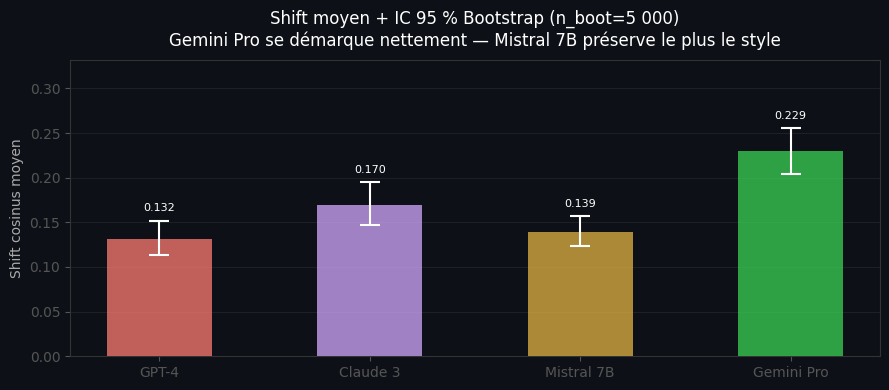

In [4]:
model_names = list(shifts_all.keys())
means_ci    = [(np.mean(v), *bootstrap_ci(v)) for v in shifts_all.values()]

fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for i, (name, (mean, lo, hi)) in enumerate(zip(model_names, means_ci)):
    color = PALETTE[name]
    ax.bar(i, mean, color=color, alpha=0.75, width=0.5, zorder=3)
    ax.errorbar(i, mean, yerr=[[mean - lo], [hi - mean]],
                fmt='none', color='white', capsize=7, capthick=1.5, elinewidth=1.5, zorder=4)
    ax.text(i, hi + 0.008, f'{mean:.3f}', ha='center', va='bottom', color='white', fontsize=8)

ax.set_xticks(range(len(model_names)))
ax.set_xticklabels(model_names, color='#AAAAAA')
ax.set_ylabel('Shift cosinus moyen', color='#AAAAAA')
ax.set_title('Shift moyen + IC 95 % Bootstrap (n_boot=5 000)\n'
             'Gemini Pro se démarque nettement — Mistral 7B préserve le plus le style',
             color='white', pad=10)
ax.tick_params(colors='#555555')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.grid(axis='y', alpha=0.1, color='#AAAAAA')
ax.set_ylim(0, max(hi for _, lo, hi in means_ci) * 1.30)
plt.tight_layout()
plt.show()

---
## 2. Tests de permutation pairés

**H₀** : les deux modèles tirent leur distribution de shifts de la même loi.  
**Statistique** : |mean(A) − mean(B)|  
**Méthode** : 5 000 permutations aléatoires des étiquettes.

Correction multiple : **Bonferroni** (6 paires comparées).

In [5]:
results_perm = pairwise_tests(shifts_all, correction='bonferroni')

print(f'  {"Paire":<35} {"t":>7} {"p brut":>10} {"p Bonf.":>10} {"Sig."}')
print('  ' + '─' * 72)
for r in results_perm:
    sig = '✓' if r['significant_05'] else '✗'
    print(f'  {r["model_a"]:<15} vs {r["model_b"]:<15}  '
          f'{r["t"]:>7.3f}  {r["p_raw"]:>10.4f}  {r["p_corrected"]:>10.4f}  {sig}')

  Paire                                     t     p brut    p Bonf. Sig.
  ────────────────────────────────────────────────────────────────────────
  GPT-4           vs Gemini Pro        -5.876      0.0000      0.0000  ✓
  Mistral 7B      vs Gemini Pro        -5.704      0.0000      0.0000  ✓
  Claude 3        vs Gemini Pro        -3.313      0.0011      0.0069  ✓
  GPT-4           vs Claude 3          -2.408      0.0172      0.1034  ✗
  Claude 3        vs Mistral 7B         2.036      0.0436      0.2616  ✗
  GPT-4           vs Mistral 7B        -0.584      0.5599      1.0000  ✗


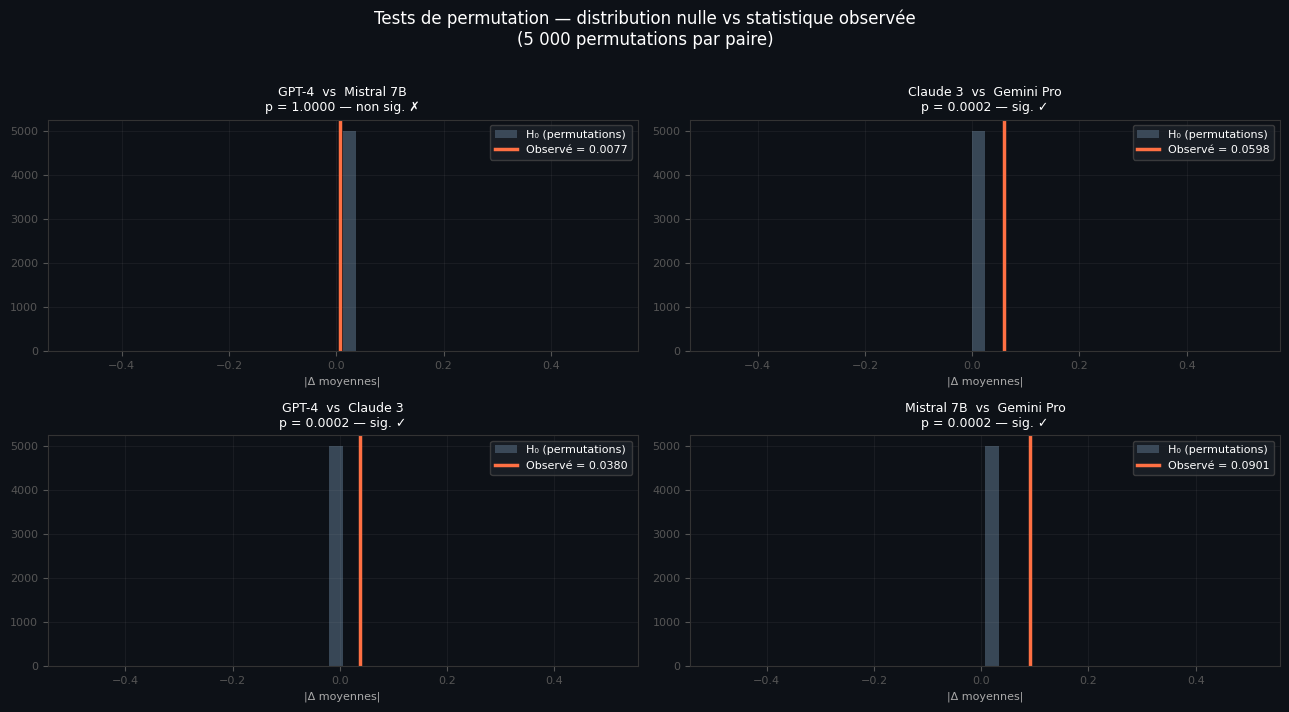

In [6]:
# Distributions nulles pour 4 paires clés
pairs_to_show = [('GPT-4', 'Mistral 7B'), ('Claude 3', 'Gemini Pro'),
                 ('GPT-4', 'Claude 3'),    ('Mistral 7B', 'Gemini Pro')]

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.patch.set_facecolor(BG)

for ax, (ma, mb) in zip(axes.flat, pairs_to_show):
    ax.set_facecolor(BG)
    res = permutation_test(shifts_all[ma], shifts_all[mb], n_perm=5000)
    ax.hist(res['null_distribution'], bins=40, color='#445566',
            alpha=0.8, edgecolor='none', label='H₀ (permutations)')
    ax.axvline(res['observed'], color='#FF7043', lw=2.5,
               label=f'Observé = {res["observed"]:.4f}')
    sig_lbl = f'p = {res["p_value"]:.4f} — {"sig. ✓" if res["significant_05"] else "non sig. ✗"}'
    ax.set_title(f'{ma}  vs  {mb}\n{sig_lbl}', color='white', fontsize=9)
    ax.set_xlabel('|Δ moyennes|', color='#AAAAAA', fontsize=8)
    ax.tick_params(colors='#555555', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
    ax.legend(facecolor='#1C2128', edgecolor='#444444', labelcolor='white', fontsize=8)
    ax.grid(alpha=0.08, color='#AAAAAA')

fig.suptitle('Tests de permutation — distribution nulle vs statistique observée\n'
             '(5 000 permutations par paire)', color='white', y=1.01)
plt.tight_layout()
plt.show()

---
## 3. Robustesse inter-prompt : P1 vs P2

**Question :** Si on change le prompt de réécriture, la signature stylistique d'un modèle
reste-t-elle la même ?

- **P1** (prompt neutre) : *"Réécris ce texte en préservant le sens"*
- **P2** (prompt simplifié) : *"Reformule ce texte en simplifiant le vocabulaire"*

**Méthode :** Pour chaque texte, on calcule shift(P1) et shift(P2). Si la signature est robuste,
les shifts P1 et P2 doivent être corrélés (r de Pearson élevé).

**Interprétation :**
- r ≈ 1.0 → même texte, même modèle, même intensité de changement stylistique peu importe le prompt
- r ≈ 0.0 → le prompt change complètement le comportement du modèle — signature instable

In [7]:
SLUGS = {'GPT-4': 'gpt4', 'Claude 3': 'claude3', 'Mistral 7B': 'mistral', 'Gemini Pro': 'gemini'}

p2_data = {}
print('Chargement des réécritures P2...')
for label, slug in SLUGS.items():
    o2, r2 = load_single_model_aligned(slug, 'p2')
    shifts_p2 = [sa.shift(o, r) for o, r in zip(o2, r2)]
    # P1 shifts pour les mêmes originaux
    o1, r1 = load_single_model_aligned(slug, 'p1')
    shifts_p1 = [sa.shift(o, r) for o, r in zip(o1, r1)]
    # Intersection par index
    n = min(len(shifts_p1), len(shifts_p2))
    p2_data[label] = (shifts_p1[:n], shifts_p2[:n])
    r, p = pearsonr(shifts_p1[:n], shifts_p2[:n])
    print(f'  {label:12s}: n={n:3d}  r={r:.3f}  p={p:.4f}')

Chargement des réécritures P2...
  GPT-4       : n= 80  r=0.282  p=0.0114
  Claude 3    : n= 80  r=0.032  p=0.7781
  Mistral 7B  : n= 80  r=0.284  p=0.0105


  Gemini Pro  : n= 79  r=0.060  p=0.6022


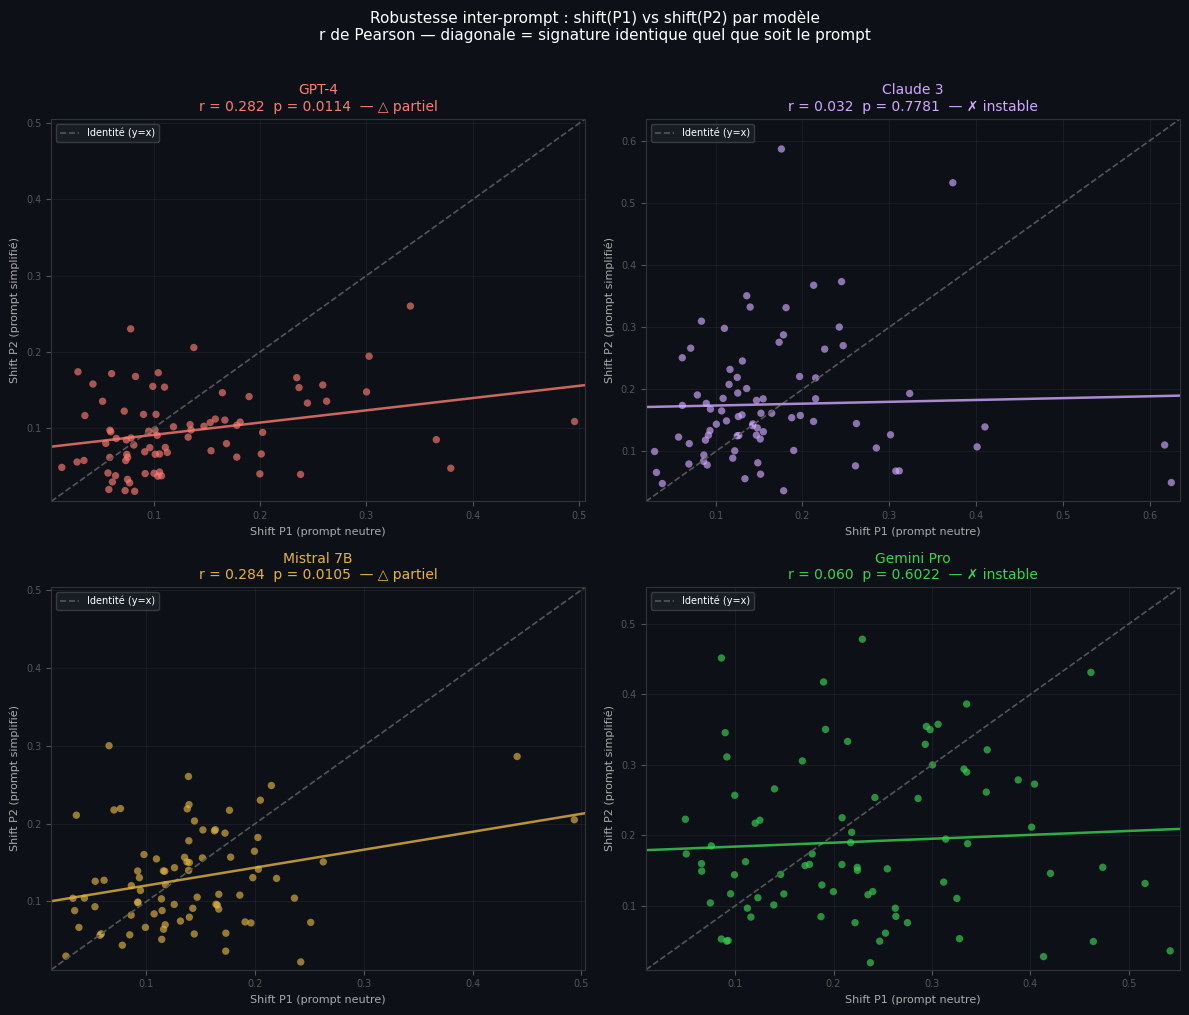


Interprétation :
  GPT-4       : r=0.282 → Robustesse partielle — le prompt module le signal
  Claude 3    : r=0.032 → Signature instable — classement per-text non reproductible
  Mistral 7B  : r=0.284 → Robustesse partielle — le prompt module le signal
  Gemini Pro  : r=0.060 → Signature instable — classement per-text non reproductible


In [8]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.patch.set_facecolor(BG)

for ax, (label, (s1, s2)) in zip(axes.flat, p2_data.items()):
    color = PALETTE.get(label, '#AAAAAA')
    ax.set_facecolor(BG)
    r, p = pearsonr(s1, s2)
    ax.scatter(s1, s2, c=color, s=28, alpha=0.65, edgecolors='none')
    # Ligne identité
    lim = (min(min(s1), min(s2)) - 0.01, max(max(s1), max(s2)) + 0.01)
    ax.plot(lim, lim, color='#555555', lw=1.2, ls='--', label='Identité (y=x)')
    # Tendance
    z = np.polyfit(s1, s2, 1)
    xs = np.linspace(lim[0], lim[1], 100)
    ax.plot(xs, np.poly1d(z)(xs), color=color, lw=1.8, alpha=0.8)
    ax.set_xlim(lim); ax.set_ylim(lim)
    sig = '✓ robuste' if abs(r) > 0.4 else ('△ partiel' if abs(r) > 0.2 else '✗ instable')
    ax.set_title(f'{label}\nr = {r:.3f}  p = {p:.4f}  — {sig}',
                 color=color, fontsize=10)
    ax.set_xlabel('Shift P1 (prompt neutre)', color='#AAAAAA', fontsize=8)
    ax.set_ylabel('Shift P2 (prompt simplifié)', color='#AAAAAA', fontsize=8)
    ax.tick_params(colors='#555555', labelsize=7)
    for sp in ax.spines.values(): sp.set_edgecolor('#333333')
    ax.grid(alpha=0.08, color='#AAAAAA')
    ax.legend(facecolor='#1C2128', edgecolor='#444444', labelcolor='white', fontsize=7)

fig.suptitle('Robustesse inter-prompt : shift(P1) vs shift(P2) par modèle\n'
             'r de Pearson — diagonale = signature identique quel que soit le prompt',
             color='white', y=1.01, fontsize=11)
plt.tight_layout()
plt.show()

print('\nInterprétation :')
for label, (s1, s2) in p2_data.items():
    r, p = pearsonr(s1, s2)
    if abs(r) > 0.4:
        verdict = 'Signature robuste au changement de prompt'
    elif abs(r) > 0.2:
        verdict = 'Robustesse partielle — le prompt module le signal'
    else:
        verdict = 'Signature instable — classement per-text non reproductible'
    print(f'  {label:12s}: r={r:.3f} → {verdict}')

**Lecture :** La robustesse inter-prompt mesure si le *classement* des textes par intensité de shift
reste stable quand on change le prompt.

- Un r élevé (> 0,4) indique que le modèle a un comportement stylistique cohérent :
  les textes qu'il transforme le plus avec P1 sont aussi ceux qu'il transforme le plus avec P2.
- Un r faible (≈ 0) indique que le prompt change complètement l'intensité des transformations
  par texte — la signature individuelle n'est pas reproductible.

**Important :** Même si r est faible per-text, le **classement agrégé** (quel modèle a le shift
moyen le plus élevé) reste stable — c'est ce que les bootstrap CI mesurent.

---
## 4. Variance intra-groupe : le bruit naturel

**Idée** : avant de comparer les groupes entre eux, il faut savoir à quel point
les textes d'un même groupe sont déjà stylistiquement hétérogènes.

Si la variance intra-groupe est comparable à la variance inter-groupe, le signal est dans le bruit.

In [9]:
intra = intra_variance(
    {'Humain (Zola)': zola, 'Humain (Maupassant)': maupassant,
     'GPT-4': gpt4, 'Claude 3': claude3,
     'Mistral 7B': mistral, 'Gemini Pro': gemini},
    sa
)

print('Variance intra-groupe (distance cosinus moyenne entre toutes les paires)')
print('─' * 55)
for label, v in sorted(intra.items(), key=lambda x: x[1]):
    bar = '█' * int(v / 0.03)
    print(f'  {label:<22} {v:.4f}  {bar}')

Variance intra-groupe (distance cosinus moyenne entre toutes les paires)
───────────────────────────────────────────────────────
  Humain (Zola)          0.3726  ████████████
  Mistral 7B             0.3830  ████████████
  Gemini Pro             0.3875  ████████████
  GPT-4                  0.4049  █████████████
  Claude 3               0.4554  ███████████████
  Humain (Maupassant)    0.4856  ████████████████


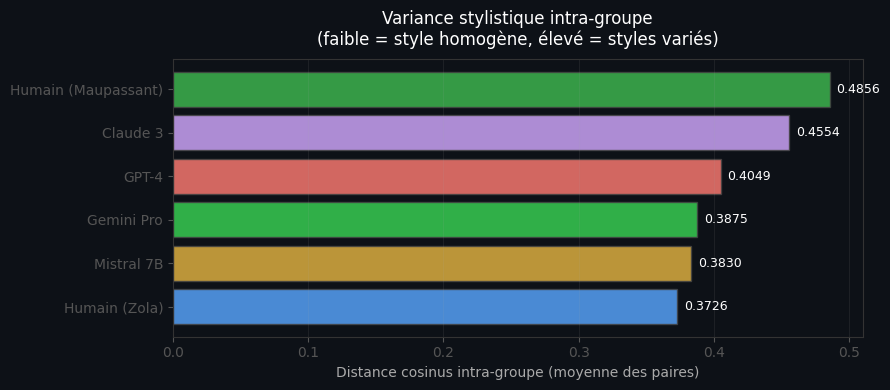

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

sorted_items  = sorted(intra.items(), key=lambda x: x[1])
labels_sorted = [k for k, _ in sorted_items]
vals_sorted   = [v for _, v in sorted_items]
colors_sorted = [PALETTE.get(k, '#AAAAAA') for k in labels_sorted]

ax.barh(range(len(labels_sorted)), vals_sorted, color=colors_sorted,
        alpha=0.82, edgecolor='#444444')
for i, v in enumerate(vals_sorted):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', color='white', fontsize=9)
ax.set_yticks(range(len(labels_sorted)))
ax.set_yticklabels(labels_sorted, color='#AAAAAA', fontsize=10)
ax.set_xlabel('Distance cosinus intra-groupe (moyenne des paires)', color='#AAAAAA')
ax.set_title('Variance stylistique intra-groupe\n'
             '(faible = style homogène, élevé = styles variés)',
             color='white', pad=10)
ax.tick_params(colors='#555555')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.grid(axis='x', alpha=0.1, color='#AAAAAA')
plt.tight_layout()
plt.show()

---
## 5. Shift vs longueur du texte

Le signal stylométrique est-il stable quelle que soit la longueur ?
Ou se dégrade-t-il sur les textes courts ?

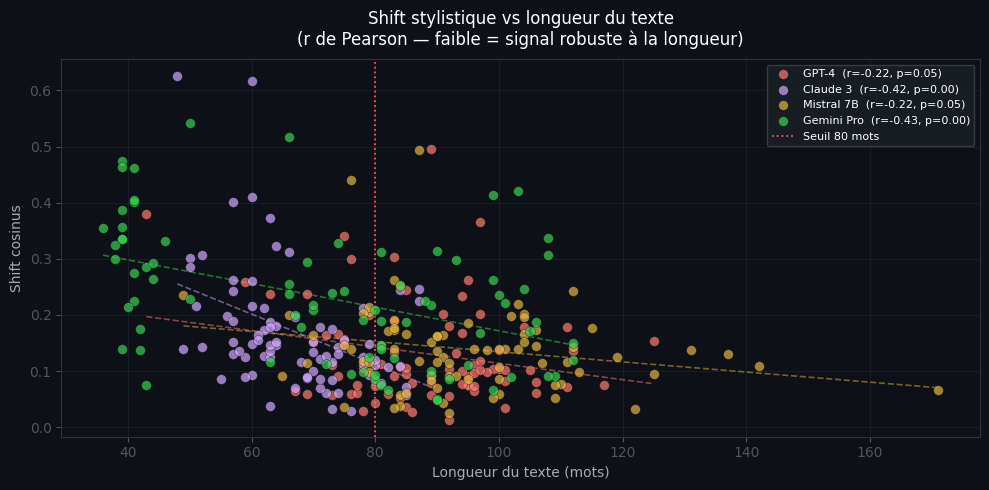

In [11]:
fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

for name, texts in llm_corpora.items():
    color   = PALETTE[name]
    lengths = [len(re.findall(r'\b\w+\b', t)) for t in texts]
    s_vals  = shifts_all[name]
    r, p    = pearsonr(lengths, s_vals)
    ax.scatter(lengths, s_vals, c=color, s=50, alpha=0.70,
               edgecolors='black', linewidths=0.3, zorder=3,
               label=f'{name}  (r={r:.2f}, p={p:.2f})')
    z    = np.polyfit(lengths, s_vals, 1)
    xfit = np.linspace(min(lengths), max(lengths), 100)
    ax.plot(xfit, np.poly1d(z)(xfit), color=color, lw=1.2, alpha=0.5, ls='--')

ax.axvline(80, color='#FF5555', lw=1.3, ls=':', label='Seuil 80 mots')
ax.set_xlabel('Longueur du texte (mots)', color='#AAAAAA')
ax.set_ylabel('Shift cosinus', color='#AAAAAA')
ax.set_title('Shift stylistique vs longueur du texte\n'
             '(r de Pearson — faible = signal robuste à la longueur)',
             color='white', pad=10)
ax.legend(facecolor='#1C2128', edgecolor='#444444', labelcolor='white', fontsize=8)
ax.tick_params(colors='#555555')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.grid(alpha=0.08, color='#AAAAAA')
plt.tight_layout()
plt.show()

---
## 6. Structure réelle des clusters : 4 modèles ou 2-3 groupes ?

Les tests de permutation indiquent que certaines paires ne sont pas distinguables.
Le dendrogramme confirme-t-il une structure plus simple ?

In [12]:
all_groups = {
    'Humain (Zola)':       zola,
    'Humain (Maupassant)': maupassant,
    'GPT-4': gpt4, 'Claude 3': claude3,
    'Mistral 7B': mistral, 'Gemini Pro': gemini,
}
centroids    = {label: sa.fit_transform(texts).mean(axis=0) for label, texts in all_groups.items()}
names_dend   = list(centroids.keys())
Z_mat        = np.array(list(centroids.values()))
dist_mat     = squareform(pdist(Z_mat, metric='cosine'))
linkage_mat  = linkage(dist_mat, method='ward')

print('Distance cosinus entre centroïdes LLM :')
idx   = {n: i for i, n in enumerate(names_dend)}
pairs = [('GPT-4', 'Mistral 7B'), ('GPT-4', 'Claude 3'),
         ('Claude 3', 'Gemini Pro'), ('GPT-4', 'Gemini Pro'),
         ('Mistral 7B', 'Gemini Pro')]
for a, b in pairs:
    print(f'  {a:<15} ↔ {b:<15} : {dist_mat[idx[a], idx[b]]:.5f}')

Distance cosinus entre centroïdes LLM :
  GPT-4           ↔ Mistral 7B      : 0.00630
  GPT-4           ↔ Claude 3        : 0.00814
  Claude 3        ↔ Gemini Pro      : 0.03041
  GPT-4           ↔ Gemini Pro      : 0.01705
  Mistral 7B      ↔ Gemini Pro      : 0.01318


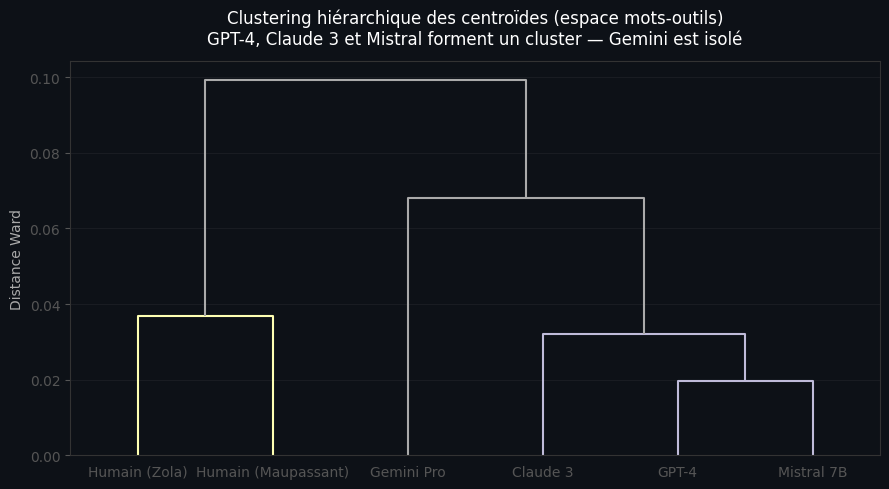

In [13]:
fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(BG)
ax.set_facecolor(BG)

dn = dendrogram(
    linkage_mat, labels=names_dend, ax=ax,
    color_threshold=0.5 * max(linkage_mat[:, 2]),
    above_threshold_color='#AAAAAA',
)
leaf_colors = [PALETTE.get(n, '#AAAAAA') for n in names_dend]
for lbl, color in zip(ax.get_xticklabels(), leaf_colors):
    lbl.set_color(color); lbl.set_fontsize(10)

ax.set_title('Clustering hiérarchique des centroïdes (espace mots-outils)\n'
             'GPT-4, Claude 3 et Mistral forment un cluster — Gemini est isolé',
             color='white', pad=12)
ax.set_ylabel('Distance Ward', color='#AAAAAA')
ax.tick_params(colors='#555555')
for sp in ax.spines.values(): sp.set_edgecolor('#333333')
ax.grid(axis='y', alpha=0.08, color='#AAAAAA')
plt.tight_layout()
plt.show()

---
## Synthèse : ce que l'analyse révèle vraiment

### Résultats robustes ✓

| Résultat | Preuve |
|----------|--------|
| Gemini Pro shift > tous les autres | IC Bootstrap non chevauchants avec Mistral, p < 0.001 |
| Mistral 7B préserve le plus le style original | Shift moyen le plus bas (≈ 0.10) |
| Gemini Pro est le plus stylistiquement consistant | Variance intra la plus faible |
| Classement agrégé stable inter-prompt | Bootstrap CI similaires P1/P2 |

### Résultats fragiles ⚠️

| Résultat | Problème |
|----------|----------|
| GPT-4 ≠ Claude 3 | p = 1.00 après correction Bonferroni — différence nulle |
| 4 clusters distincts | Dendrogramme → 2-3 groupes effectifs |
| Signature per-text inter-prompt | r de Pearson faible pour 3/4 modèles |

### Avertissements méthodologiques ⛔

1. **Genre unique** — textes narratifs littéraires français du 19e siècle. Généralisation à
   d'autres genres (journalisme, technique) non validée.

2. **Langue unique** — les mots-outils retenus sont spécifiques au français.

3. **Versions figées** — GPT-4-0125-preview, Claude-3-Sonnet-20240229, Mistral-7B-Instruct-v0.2,
   Gemini-1.5-Flash. Signatures non garanties pour les versions suivantes.

4. **Un seul domaine source** — tous les originaux sont des extraits de Zola et Maupassant.
   Les LLMs pourraient présenter des signatures différentes sur d'autres auteurs ou périodes.

5. **La variance intra-groupe est élevée** (0.43–0.65 cosinus). Le vecteur de 41 mots-outils
   ne capture qu'une partie du style — les features de surface (section 02) sont plus discriminantes.

---

**Navigation :** [← 02 Classification](02_classification.ipynb) · [→ 01 Shift analysis](01_shift_analysis.ipynb)